# Notebook 06 — CARMA(2,1) Estimation and Lévy Recovery — Temperature

Estimates a CARMA$(2,1)$ model for deseasonalized temperature residuals $Y_t$ via quasi-maximum likelihood (yuima::qmle, L-BFGS-B optimizer, time step $h = 1/8760$ yr). Recovers Lévy driving increments $\Delta L^Y$ using a stationary Kalman filter followed by the canonical state transformation and formula (16) of Brockwell, Davis & Yang (2011), integrated via the trapezoid rule. Fits a Normal Inverse Gaussian (NIG) distribution to $\Delta L^Y$. Estimates the coupling coefficient $\hat{\gamma}$ by OLS regression of $\Delta L^X$ on $\Delta L^Y$.

> **Implementation note — Lévy recovery:** yuima's native `CarmaNoise` uses numerical (finite-difference) derivatives to reconstruct state vectors, which diverges on long, noisy series. This notebook replaces it with a stationary Kalman filter ($R_{\text{obs}} \to 0$) followed by the canonical eigendecomposition and formula (16), integrated via the trapezoid rule. This is numerically stable for $n > 50\,000$ observations.

**Inputs:** `data/deseasonalised/temp_resid.csv`, `data/levy/price_levy_increments.csv`  
**Outputs:** `data/levy/temp_levy_increments.csv`

### Step 1 — ARIMA(2,0,1) baseline fit

Fits a discrete-time ARIMA(2,0,1) model to the zero-mean deseasonalized temperature residuals as a preliminary diagnostic. The estimated AR/MA coefficients serve as cross-checks for the CARMA$(2,1)$ eigenvalues derived in notebook 04, and their hourly-scale values provide starting points for the QMLE in Steps 3–4.

In [1]:
# Load data
temp_resid <- read.csv("../data/deseasonalised/temp_resid.csv", row.names = 1)

# Deseasonalized temperature series
temp_res <- temp_resid$temp_deseasoned

# Fit ARIMA(2,0,1) without mean (residuals are already zero-mean)
temp_model <- arima(temp_res, order = c(2, 0, 1), include.mean = FALSE, method = "CSS-ML")

# Coefficients and standard errors
coef(temp_model)
aic <- temp_model$aic
cat(sprintf("AIC = %.2f\n", aic))
se <- sqrt(diag(temp_model$var.coef))
print(se)
summary(temp_model)

ar1        ar2        ma1 
 1.4070312 -0.4237434 -0.1393253

AIC = 97037.74
       ar1        ar2        ma1 
0.01327419 0.01308704 0.01454691 


          Length Class  Mode     
coef          3  -none- numeric  
sigma2        1  -none- numeric  
var.coef      9  -none- numeric  
mask          3  -none- logical  
loglik        1  -none- numeric  
aic           1  -none- numeric  
arma          7  -none- numeric  
residuals 52608  ts     numeric  
call          5  -none- call     
series        1  -none- character
code          1  -none- numeric  
n.cond        1  -none- numeric  
nobs          1  -none- numeric  
model        10  -none- list     

In [2]:
library(Matrix)

df <- read.csv("../data/deseasonalised/temp_resid.csv", row.names = 1)
y  <- as.numeric(df[[1]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

# Initial AR coefficients (hourly scale, from ARIMA(2,0,1) above)
a_init <- c(0.90926095, 0.02497772)
b_init <- c(1, 0.5)

p <- 2

# Companion matrix A
A <- matrix(0, p, p)
for (i in 1:(p - 1)) A[i, i + 1] <- 1
A[p, ] <- -rev(a_init)

# Solve continuous Lyapunov: A*Sigma + Sigma*A' + ep*ep' = 0
ep <- matrix(0, p, 1); ep[p] <- 1
Q  <- ep %*% t(ep)

Sigma_norm <- matrix(
  solve(kronecker(diag(p), A) + kronecker(A, diag(p)), -as.vector(Q)),
  p, p
)

b_vec    <- b_init
var_norm <- as.numeric(t(b_vec) %*% Sigma_norm %*% b_vec)
sig_init <- sd(y) / sqrt(var_norm)

cat(sprintf("sd(y)    = %.6f\n", sd(y)))
cat(sprintf("var_norm = %.6f\n", var_norm))
cat(sprintf("sig_init = %.6f\n", sig_init))

sd(y)    = 3.793149
var_norm = 22.152980
sig_init = 0.805905


### Step 2 — Initial scale calibration

Computes a preliminary estimate of the driving noise scale $\sigma$ by solving the **continuous Lyapunov equation**
$$A\Sigma_\infty + \Sigma_\infty A^\top + \mathbf{e}_p\mathbf{e}_p^\top = 0$$
for the unit-variance stationary covariance $\Sigma_\infty$. Setting $\mathbf{b}^\top \Sigma_\infty \mathbf{b} = \widehat{\text{Var}}(r_t^Y)$ yields a closed-form initial $\sigma$, which stabilizes the QMLE optimization and avoids divergence from poor starting values.

### Step 3 — QMLE at hourly scale (preliminary)

First-pass quasi-maximum likelihood estimation with time unit $h = 1$ hr using the **yuima** package (L-BFGS-B optimizer). Minimizes the negative Gaussian quasi-log-likelihood over $(a_1, a_2, b_0, b_1, \sigma)$. The hourly-scale estimates are then rescaled to yr⁻¹ in Step 4 for interpretability and cross-comparison with the literature.

In [3]:
library(yuima)

fit_carma21 <- function(
  csv_path  = "../data/deseasonalised/temp_resid.csv",
  value_col = "temp_deseasoned",
  h         = 1
) {
  # Load and centre data
  df <- read.csv(csv_path, row.names = 1)
  y  <- as.numeric(df[[value_col]])
  y  <- y[is.finite(y)]
  y  <- y - mean(y)

  dat <- setData(matrix(y, ncol = 1), delta = h)

  # CARMA(2,1) model specification
  mod <- setCarma(p = 2, q = 1, scale.par = "sig", Carma.var = "y")
  yu  <- setYuima(model = mod, data = dat)
  

  # Starting values (hourly scale, h = 1)
  start <- list(
    a1  = 0.90926095,
    a2  = 0.02497772,
    b0  = 1.000,
    b1  = 0.5,
    sig = 0.7921462
  )

  cat("=== INITIAL PARAMETERS ===\n")
  for (nm in names(start)) cat(sprintf("  %-4s = %g\n", nm, start[[nm]]))

  # QMLE estimation
  est <- qmle(yuima = yu, start = start)

  cat("\n=== NEGATIVE LOG-LIKELIHOOD ===\n")
  cat(sprintf("  -2 log L = %.4f\n", est@min))

  cat("\n=== ESTIMATED COEFFICIENTS ===\n")
  print(coef(est))

  cat("\n=== SUMMARY ===\n")
  print(summary(est))

  return(est)
}

est <- fit_carma21()

Le chargement a nécessité le package : zoo


Attachement du package : 'zoo'


Les objets suivants sont masqués depuis 'package:base':

    as.Date, as.Date.numeric


Le chargement a nécessité le package : stats4

Le chargement a nécessité le package : expm


Attachement du package : 'expm'


L'objet suivant est masqué depuis 'package:Matrix':

    expm


Le chargement a nécessité le package : cubature

Le chargement a nécessité le package : mvtnorm

########################################

This is YUIMA Project package v.1.15.34

Why don't you try yuimaGUI package?

Visit: http://www.yuima-project.com

########################################


Attachement du package : 'yuima'


L'objet suivant est masqué depuis 'package:stats':

    simulate




=== INITIAL PARAMETERS ===
  a1   = 0.909261
  a2   = 0.0249777
  b0   = 1
  b1   = 0.5
  sig  = 0.792146

Starting qmle for carma ... 


Warning message in yuima.warn("Drift and diffusion parameters must be different. Doing\n               joint estimation, asymptotic theory may not hold true."):
"
YUIMA: Drift and diffusion parameters must be different. Doing
               joint estimation, asymptotic theory may not hold true.
"



=== NEGATIVE LOG-LIKELIHOOD ===
  -2 log L = 48514.8734

=== ESTIMATED COEFFICIENTS ===
       sig         b1         b0         a2         a1 
0.76963298 0.58442089 1.00000000 0.02473622 0.83460255 

=== SUMMARY ===
Quasi-Maximum likelihood estimation

Call:
qmle(yuima = yu, start = start)

Coefficients:
      Estimate  Std. Error
sig 0.76963298 0.022897473
b1  0.58442089 0.022641470
b0  1.00000000 0.000000000
a2  0.02473622 0.001068364
a1  0.83460255 0.030249628

-2 log L: 97029.75 

Carma(2,1) model: Stationarity conditions are satisfied.


In [4]:
cf     <- coef(est)
ar.par <- c(cf["a1"], cf["a2"])
ma.par <- c(cf["b0"], cf["b1"]) * cf["sig"]

dir.create("../data/kalman", showWarnings = FALSE, recursive = TRUE)

write.csv(
  data.frame(
    name  = c("a1", "a2", "b0", "b1", "sig",
              "ma0", "ma1"),
    value = c(cf["a1"], cf["a2"], cf["b0"], cf["b1"], cf["sig"],
              ma.par[1], ma.par[2])
  ),
  "../data/kalman/temp_carma_params.csv",
  row.names = FALSE
)
cat("Saved temp_carma_params.csv\n")
print(read.csv("../data/kalman/temp_carma_params.csv"))

Saved temp_carma_params.csv


  name      value
1   a1 0.83460255
2   a2 0.02473622
3   b0 1.00000000
4   b1 0.58442089
5  sig 0.76963298
6  ma0 0.76963298
7  ma1 0.44978959


### Step 4 — QMLE at annual scale — final model

Re-runs QMLE with $h = 1/8760$ yr so that all eigenvalues $\lambda_i$ and the noise scale $\sigma$ are expressed in yr⁻¹. This is the **definitive CARMA$(2,1)$ parameter set** used in all downstream steps. Stationarity is verified by confirming $\operatorname{Re}(\lambda_i) < 0$ for both eigenvalues, and half-lives are reported in hours for interpretability.

In [ ]:
library(yuima)

df <- read.csv("../data/deseasonalised/temp_resid.csv", row.names = 1)
y  <- as.numeric(df[["temp_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

h <- 1 / 8760   # time step in years (1 hour = 1/8760 yr)

dat <- setData(matrix(y, ncol = 1), delta = h)
mod <- setCarma(p = 2, q = 1, scale.par = "sig", Carma.var = "y")
yu  <- setYuima(model = mod, data = dat)

# Convert hourly-scale ARMA coefficients to annual-scale CARMA starting values
scale <- 8760
a_h   <- c(0.90926095, 0.02497772)
A_h   <- matrix(0, 2, 2); A_h[1, 2] <- 1; A_h[2, ] <- -rev(a_h)
A_yr  <- scale * A_h

start <- list(
  a1  = -A_yr[2, 2],
  a2  = -A_yr[2, 1],
  b0  = 1,
  b1  = 0.56916460,
  sig = 0.79214621 * sqrt(scale)
)

cat("=== INITIAL PARAMETERS (yr\u207b\u00b9) ===\n")
for (nm in names(start)) cat(sprintf("  %-4s = %g\n", nm, start[[nm]]))

est <- suppressWarnings(qmle(
  yuima  = yu, start = start,
  lower  = list(sig = 1e-6),
  method = "L-BFGS-B"
))

cf       <- coef(est)
loglik   <- -est@min
n_params <- length(cf)
aic      <- 2 * n_params - 2 * loglik

cat("\n=== ESTIMATED PARAMETERS (yr\u207b\u00b9) ===\n")
for (nm in names(cf)) cat(sprintf("  %-4s = %g\n", nm, cf[[nm]]))

# Eigenvalues and half-lives
a_final <- c(cf["a1"], cf["a2"])
A_final <- matrix(0, 2, 2); A_final[1, 2] <- 1; A_final[2, ] <- -rev(a_final)
eigs    <- eigen(A_final)$values

cat("\n=== EIGENVALUES ===\n")
for (e in eigs)
  cat(sprintf("  lambda = %8.3f yr\u207b\u00b9   half-life = %.2f h\n",
              Re(e), log(2) / abs(Re(e)) * 8760))

cat("\n=== STATIONARITY ===\n")
if (all(Re(eigs) < 0)) {
  cat("  OK — all eigenvalues have negative real part\n")
} else {
  cat("  WARNING — eigenvalue with non-negative real part detected\n")
}

cat("\n=== FIT CRITERIA ===\n")
cat(sprintf("  log-lik  = %.4f\n", loglik))
cat(sprintf("  n_params = %d\n",   n_params))
cat(sprintf("  AIC      = %.4f\n", aic))

### Lévy increment recovery — custom Kalman + formula (16)

Uses a stationary Kalman filter (observation variance $R_{\text{obs}} \to 0$) to recover filtered states $\hat{Z}_t$, then applies the canonical eigendecomposition and formula (16) of Brockwell, Davis & Yang (2011):

$$\Delta L_t^Y \approx \frac{1}{\alpha_r}\Bigl[Y_r(t_k) - Y_r(t_{k-1}) - \lambda_r \int_{t_{k-1}}^{t_k} Y_r(s)\,ds\Bigr]$$

where $Y_r(t) = b(\lambda_r)\,[\mathbf{V}^{-1}\hat{Z}_t]_r$ and the integral is approximated by the trapezoid rule. The dominant real eigenvalue $\lambda_r$ is selected to ensure $b(\lambda_r) \neq 0$.

Q_proc[p,p] exact = 0.48318501  (vs Euler approx h = 1.0)
Lyapunov iteration converged in 309 steps
Stationary Kalman gain converged in 7 steps

=== CANONICAL STATE (dominant eigenvalue) ===
  lambda_r    = -0.030773 yr^-1
  b(lambda_r) = 0.755792
  1/alpha_r   = 1.022844

=== LEVY INCREMENTS dL^T ===
  N    = 52607
  Mean = 0.000008
  SD   = 0.999949
  Skew = -0.8506
  Kurt = 11.4954

=== GAUSSIAN FIT ===
  mu    = 0.000008
  sigma = 0.999949
  sigma_T (for lambda estimation) = 0.999949

Fitting NIG distribution...

=== NIG FIT ===
  alpha = 0.809286
  beta  = -0.090272
  mu    = 0.085947
  delta = 0.766712

=== GOODNESS OF FIT ===
  AIC Gaussian = 149289.9  (2 parameters)
  AIC NIG      = 137643.7  (4 parameters)
  Delta AIC    = 11646.1  (positive = NIG preferred)

  Conclusion: NIG preferred — but use sigma_gauss for lambda estimation anyway

Saved:
  temp_levy_increments.csv : 52607 rows
  temp_gauss_params.csv    : mu=0.000008  sigma=0.999949
  temp_kalman.rds          : sigma_T=

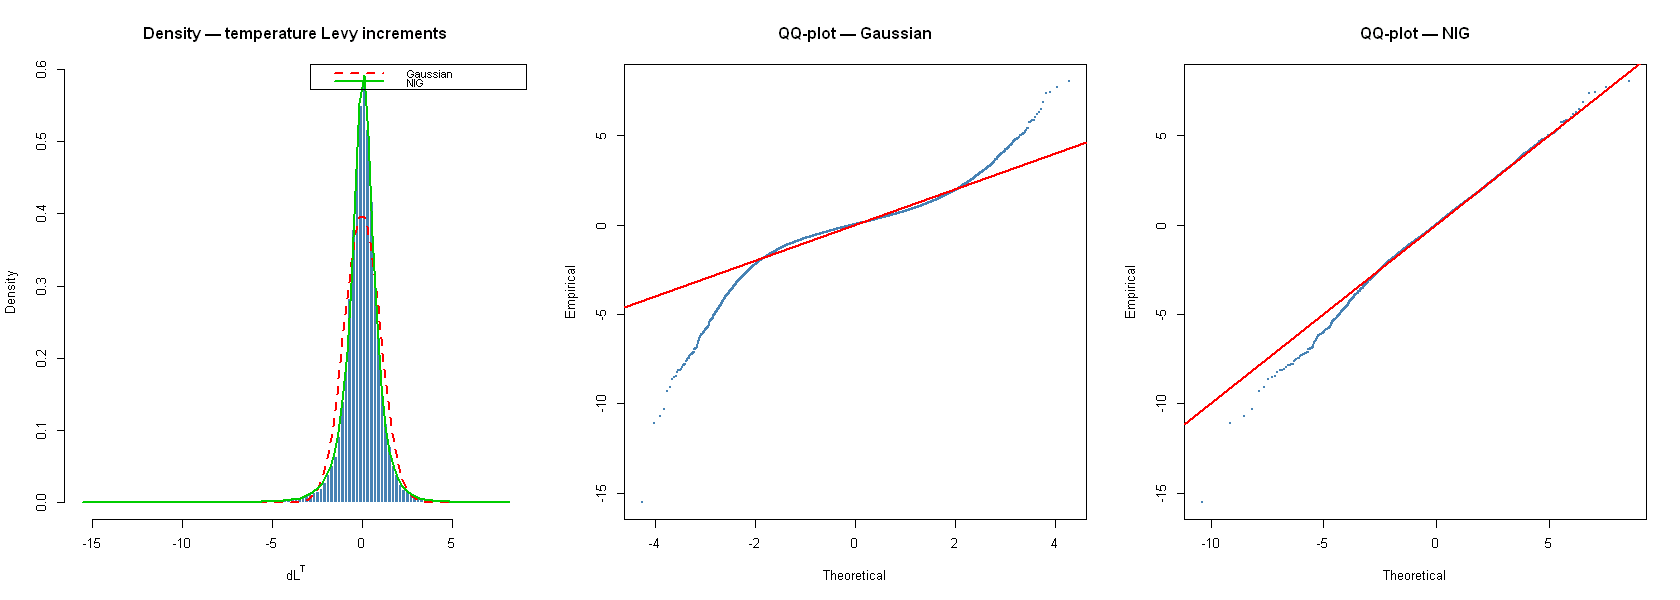

In [11]:
library(expm)
library(GeneralizedHyperbolic)

# ==================================================
# Parameters from the annual-scale QMLE
# ==================================================
cf     <- coef(est)
ar.par <- c(cf["a1"], cf["a2"])
ma.par <- c(cf["b0"], cf["b1"]) * cf["sig"]
p      <- length(ar.par)
q      <- length(ma.par)

h <- 1

df <- read.csv("../data/deseasonalised/temp_resid.csv", row.names = 1)
y  <- as.numeric(df[["temp_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)
n  <- length(y)

# ==================================================
# Companion matrix A
# ==================================================
A <- matrix(0, p, p)
if (p > 1) for (i in 1:(p - 1)) A[i, i + 1] <- 1
A[p, ] <- -ar.par[p:1]

b_vec <- rep(0, p); b_vec[1:q] <- ma.par
e_p   <- rep(0, p); e_p[p]    <- 1
eAh   <- expm(A * h)

R_obs <- .Machine$double.eps * var(y)

# Exact discrete Q via continuous Lyapunov: A*P + P*A' + e_p*e_p' = 0
P_inf_unit <- matrix(solve(kronecker(diag(p), A) + kronecker(A, diag(p)),
                           -as.vector(e_p %o% e_p)), p, p)
Q_proc     <- P_inf_unit - eAh %*% P_inf_unit %*% t(eAh)
Q_proc     <- 0.5 * (Q_proc + t(Q_proc))  # symmetrise numerically

cat(sprintf("Q_proc[p,p] exact = %.8f  (vs Euler approx h = %.1f)\n",
            Q_proc[p, p], h))

# ==================================================
# Stationary covariance via Lyapunov iteration
# ==================================================
Q_inf <- matrix(0, p, p)
for (k in 1:100000) {
  Q_new <- eAh %*% Q_inf %*% t(eAh) + Q_proc
  if (max(abs(Q_new - Q_inf)) < 1e-8) break
  Q_inf <- Q_new
}
cat(sprintf("Lyapunov iteration converged in %d steps\n", k))

# ==================================================
# Stationary Kalman gain
# ==================================================
P_ss <- Q_inf
for (k in 1:10000) {
  Pp       <- eAh %*% P_ss %*% t(eAh) + Q_proc
  S_ss     <- as.numeric(t(b_vec) %*% Pp %*% b_vec) + R_obs
  K_ss     <- (Pp %*% b_vec) / S_ss
  P_ss_new <- (diag(p) - K_ss %*% t(b_vec)) %*% Pp
  if (max(abs(P_ss_new - P_ss)) < 1e-8) break
  P_ss <- P_ss_new
}
cat(sprintf("Stationary Kalman gain converged in %d steps\n", k))

Pp_stat <- eAh %*% P_ss %*% t(eAh) + Q_proc
K_stat  <- (Pp_stat %*% b_vec) /
           (as.numeric(t(b_vec) %*% Pp_stat %*% b_vec) + R_obs)

# ==================================================
# Kalman filter — forward pass
# ==================================================
X_f <- matrix(0, n, p)
for (i in 2:n) {
  Xp       <- as.numeric(eAh %*% X_f[i - 1, ])
  X_f[i, ] <- Xp + K_stat * (y[i] - sum(b_vec * Xp))
}
X.StVa <- t(X_f)

# ==================================================
# Canonical state representation
# ==================================================
eig_A     <- eigen(A)
eig_vals  <- eig_A$values
eig_vecs  <- eig_A$vectors
BinLambda <- sapply(eig_vals, function(lam) sum(ma.par * lam^(0:(q - 1))))
Y_CVS     <- diag(BinLambda) %*% solve(eig_vecs) %*% X.StVa

idx_real <- which(abs(Im(eig_vals)) < 1e-6)
idx_r    <- idx_real[which.max(Re(eig_vals[idx_real]))]
lambda_r <- Re(eig_vals[idx_r])

cat(sprintf("\n=== CANONICAL STATE (dominant eigenvalue) ===\n"))
cat(sprintf("  lambda_r    = %.6f yr^-1\n", lambda_r))
cat(sprintf("  b(lambda_r) = %.6f\n",       Re(BinLambda[idx_r])))

ar_coeffs <- c(1, ar.par[1:p])
derA      <- sum(sapply(1:p, function(k)
               (p + 1 - k) * ar_coeffs[k] * lambda_r^(p - k)))
coeff     <- Re(derA / BinLambda[idx_r])
cat(sprintf("  1/alpha_r   = %.6f\n", coeff))

# ==================================================
# Formula (16) — Brockwell, Davis & Yang (2011)
# ==================================================
Y_r     <- Re(Y_CVS[idx_r, ])
lev_und <- numeric(n)
int_cum <- 0
for (t in 2:n) {
  int_cum    <- int_cum + 0.5 * (Y_r[t - 1] + Y_r[t]) * h
  lev_und[t] <- coeff * (Y_r[t] - Y_r[1] - lambda_r * int_cum)
}
dL <- diff(lev_und)
dL <- dL[is.finite(dL)]

cat(sprintf("\n=== LEVY INCREMENTS dL^T ===\n"))
cat(sprintf("  N    = %d\n",   length(dL)))
cat(sprintf("  Mean = %.6f\n", mean(dL)))
cat(sprintf("  SD   = %.6f\n", sd(dL)))
cat(sprintf("  Skew = %.4f\n", mean((dL - mean(dL))^3) / sd(dL)^3))
cat(sprintf("  Kurt = %.4f\n", mean((dL - mean(dL))^4) / sd(dL)^4))

# ==================================================
# Gaussian fit
# ==================================================
mu_gauss    <- mean(dL)
sigma_gauss <- sd(dL)
ll_nor      <- sum(dnorm(dL, mu_gauss, sigma_gauss, log = TRUE))

cat(sprintf("\n=== GAUSSIAN FIT ===\n"))
cat(sprintf("  mu    = %.6f\n", mu_gauss))
cat(sprintf("  sigma = %.6f\n", sigma_gauss))
cat(sprintf("  sigma_T (for lambda estimation) = %.6f\n", sigma_gauss))

# ==================================================
# NIG fit
# ==================================================
cat("\nFitting NIG distribution...\n")
fit_nig    <- suppressWarnings(nigFit(dL))
params_nig <- fit_nig$param
ll_nig     <- sum(log(dnig(dL,
                            mu    = params_nig["mu"],
                            delta = params_nig["delta"],
                            alpha = params_nig["alpha"],
                            beta  = params_nig["beta"])))

cat(sprintf("\n=== NIG FIT ===\n"))
cat(sprintf("  alpha = %.6f\n", params_nig["alpha"]))
cat(sprintf("  beta  = %.6f\n", params_nig["beta"]))
cat(sprintf("  mu    = %.6f\n", params_nig["mu"]))
cat(sprintf("  delta = %.6f\n", params_nig["delta"]))

# ==================================================
# Model comparison
# ==================================================
aic_gauss <- -2 * ll_nor + 2 * 2
aic_nig   <- -2 * ll_nig + 2 * 4

cat(sprintf("\n=== GOODNESS OF FIT ===\n"))
cat(sprintf("  AIC Gaussian = %.1f  (2 parameters)\n", aic_gauss))
cat(sprintf("  AIC NIG      = %.1f  (4 parameters)\n", aic_nig))
cat(sprintf("  Delta AIC    = %.1f  (positive = NIG preferred)\n",
            aic_gauss - aic_nig))
cat(sprintf("\n  Conclusion: %s\n",
            ifelse(aic_gauss < aic_nig,
                   "Gaussian preferred — use sigma_gauss for lambda estimation",
                   "NIG preferred — but use sigma_gauss for lambda estimation anyway")))

# ==================================================
# Plots
# ==================================================
probs <- ppoints(length(dL))
q_emp <- sort(dL)
q_nig <- qnig(probs, mu = params_nig["mu"], delta = params_nig["delta"],
              alpha = params_nig["alpha"], beta = params_nig["beta"])
q_nor <- qnorm(probs, mu_gauss, sigma_gauss)

options(repr.plot.width = 14, repr.plot.height = 5)
par(mfrow = c(1, 3))

hist(dL, breaks = 100, freq = FALSE, col = "steelblue", border = "white",
     main = "Density — temperature Levy increments", xlab = expression(dL^T))
curve(dnorm(x, mu_gauss, sigma_gauss),
      add = TRUE, col = "red", lwd = 2, lty = 2)
curve(dnig(x, mu = params_nig["mu"], delta = params_nig["delta"],
           alpha = params_nig["alpha"], beta = params_nig["beta"]),
      add = TRUE, col = "green3", lwd = 2)
legend("topright", c("Gaussian", "NIG"), col = c("red", "green3"),
       lwd = 2, lty = c(2, 1), cex = 0.8)

plot(q_nor, q_emp, pch = 16, cex = 0.3, col = "steelblue",
     main = "QQ-plot — Gaussian", xlab = "Theoretical", ylab = "Empirical")
abline(0, 1, col = "red", lwd = 2)

plot(q_nig, q_emp, pch = 16, cex = 0.3, col = "steelblue",
     main = "QQ-plot — NIG", xlab = "Theoretical", ylab = "Empirical")
abline(0, 1, col = "red", lwd = 2)

par(mfrow = c(1, 1))

# ==================================================
# Save
# ==================================================
dir.create("../data/levy",   showWarnings = FALSE, recursive = TRUE)
dir.create("../data/kalman", showWarnings = FALSE, recursive = TRUE)

write.csv(
  data.frame(
    datetime = format(as.POSIXct(rownames(df), tz = "UTC")[2:n],
                      "%Y-%m-%d %H:%M:%S"),
    dL = dL
  ),
  "../data/levy/temp_levy_increments.csv",
  row.names = FALSE
)

write.csv(
  data.frame(
    parameter = c("mu_gauss", "sigma_gauss"),
    value     = c(mu_gauss,   sigma_gauss)
  ),
  "../data/kalman/temp_gauss_params.csv",
  row.names = FALSE
)

innov_T <- numeric(n - 1)
for (i in 2:n)
  innov_T[i - 1] <- y[i] - sum(b_vec * as.numeric(eAh %*% X_f[i - 1, ]))

saveRDS(list(
  innov   = innov_T,
  dates   = as.POSIXct(rownames(df), tz = "UTC")[2:n],
  A       = A,
  b_vec   = b_vec,
  e_p     = e_p,
  h       = h,
  sigma_T = sigma_gauss
), "../data/kalman/temp_kalman.rds")

write.csv(
  data.frame(row = rep(1:p, p), col = rep(1:p, each = p), val = as.vector(A)),
  "../data/kalman/temp_A.csv", row.names = FALSE
)
write.csv(
  data.frame(b = b_vec),
  "../data/kalman/temp_b.csv", row.names = FALSE
)

write.csv(
  data.frame(
    datetime = format(as.POSIXct(rownames(df), tz = "UTC")[2:n],
                      "%Y-%m-%d %H:%M:%S"),
    as.data.frame(X_f[2:n, ])
  ),
  "../data/kalman/temp_states.csv",
  row.names = FALSE
)

cat(sprintf("\nSaved:\n"))
cat(sprintf("  temp_levy_increments.csv : %d rows\n", length(dL)))
cat(sprintf("  temp_gauss_params.csv    : mu=%.6f  sigma=%.6f\n",
            mu_gauss, sigma_gauss))
cat(sprintf("  temp_kalman.rds          : sigma_T=%.6f\n", sigma_gauss))
cat(sprintf("  temp_A.csv, temp_b.csv   : CARMA matrices\n"))
cat(sprintf("  temp_states.csv          : %d x %d Kalman states\n",
            n - 1, p))

In [6]:
# rownames(df) sont des timestamps horaires ex: "2020-01-01 00:00:00"
innov_T <- numeric(n - 1)
for (i in 2:n)
  innov_T[i - 1] <- y[i] - sum(b_vec * as.numeric(eAh %*% X_f[i - 1, ]))

saveRDS(list(
  innov   = innov_T,
  dates   = as.POSIXct(rownames(df), tz = "UTC")[2:n],
  A       = A,
  b_vec   = b_vec,
  e_p     = e_p,
  h       = h,
  sigma_T = sd(dL)
), "../data/kalman/temp_kalman.rds")
cat(sprintf("Saved: %d hourly innovations\n", length(innov_T)))

Saved: 52607 hourly innovations


In [7]:
saveRDS(list(
  x_filt  = X_f,
  innov   = innov_T,
  dates   = as.POSIXct(rownames(df), tz = "UTC")[2:n],
  A       = A,
  b_vec   = b_vec,
  e_p     = e_p,
  sigma_T = sd(dL),
  h       = h
), "../data/kalman/temp_kalman_full.rds")

In [8]:
df_export <- data.frame(
  datetime = format(as.POSIXct(rownames(df), tz = "UTC")[2:n], "%Y-%m-%d %H:%M:%S"),
  innov_T  = innov_T
)
write.csv(df_export, "../data/kalman/temp_innovations.csv", row.names = FALSE)

In [9]:
# Add to temperature R notebook
write.csv(
  data.frame(
    row = rep(1:p, p), col = rep(1:p, each = p),
    val = as.vector(A)
  ),
  "../data/kalman/temp_A.csv", row.names = FALSE
)
write.csv(
  data.frame(b = b_vec),
  "../data/kalman/temp_b.csv", row.names = FALSE
)

In [10]:
# Export A_T and b_T for Python
dir.create("../data/kalman", showWarnings = FALSE, recursive = TRUE)

write.csv(
  data.frame(row = rep(1:p, p), col = rep(1:p, each = p), val = as.vector(A)),
  "../data/kalman/temp_A.csv", row.names = FALSE
)
write.csv(
  data.frame(b = b_vec),
  "../data/kalman/temp_b.csv", row.names = FALSE
)
cat("Exported A_T and b_T\n")

Exported A_T and b_T


### AIC comparison — CARMA(2,1) vs OU/CARMA(1,0)

Fits a simpler Ornstein–Uhlenbeck process (CARMA$(1,0)$) as a nested benchmark. Comparing AIC values between the two models determines whether the second mean-reversion timescale in CARMA$(2,1)$ provides a statistically significant improvement over the single-factor OU model.

In [2]:
library(yuima)

# OU / CARMA(1,0) model for comparison — one mean-reversion rate only
df <- read.csv("../data/deseasonalised/temp_resid.csv", row.names = 1)
y  <- as.numeric(df[[1]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

h <- 1 

dat <- setData(matrix(y, ncol = 1), delta = h)
mod <- setCarma(p = 1, q = 0, scale.par = "sig", Carma.var = "y")
yu  <- setYuima(model = mod, data = dat)

# Starting values: convert hourly OU mean-reversion to annual scale
start <- list(
  a1  = 1,
  b0  = 1,
  sig = 0.029 * sqrt(8760)
)

cat("=== INITIAL PARAMETERS — OU / CARMA(1,0) (yr\u207b\u00b9) ===\n")
for (nm in names(start)) cat(sprintf("  %-4s = %g\n", nm, start[[nm]]))

est_ou <- suppressWarnings(qmle(
  yuima  = yu, start = start,
  lower  = list(sig = 1e-6),
  method = "L-BFGS-B"
))

cf_ou    <- coef(est_ou)
loglik   <- -est_ou@min
n_params <- length(cf_ou)
aic      <- 2 * n_params - 2 * loglik

cat("\n=== ESTIMATED PARAMETERS — OU / CARMA(1,0) (yr\u207b\u00b9) ===\n")
for (nm in names(cf_ou)) cat(sprintf("  %-4s = %g\n", nm, cf_ou[[nm]]))

cat(sprintf("\n  lambda = %.4f yr\u207b\u00b9   half-life = %.2f h\n",
            -cf_ou["a1"], log(2) / cf_ou["a1"] * 8760))

cat(sprintf("\n=== FIT CRITERIA ===\n"))
cat(sprintf("  log-lik  = %.4f\n", loglik))
cat(sprintf("  n_params = %d\n",   n_params))
cat(sprintf("  AIC      = %.4f\n", aic))

Le chargement a nécessité le package : zoo


Attachement du package : 'zoo'


Les objets suivants sont masqués depuis 'package:base':

    as.Date, as.Date.numeric


Le chargement a nécessité le package : stats4

Le chargement a nécessité le package : expm

Le chargement a nécessité le package : Matrix


Attachement du package : 'expm'


L'objet suivant est masqué depuis 'package:Matrix':

    expm


Le chargement a nécessité le package : cubature

Le chargement a nécessité le package : mvtnorm

########################################

This is YUIMA Project package v.1.15.34

Why don't you try yuimaGUI package?

Visit: http://www.yuima-project.com

########################################


Attachement du package : 'yuima'


L'objet suivant est masqué depuis 'package:stats':

    simulate




=== INITIAL PARAMETERS — OU / CARMA(1,0) (yr⁻¹) ===
  a1   = 1
  b0   = 1
  sig  = 2.71425

Starting qmle for carma ... 

=== ESTIMATED PARAMETERS — OU / CARMA(1,0) (yr⁻¹) ===
  sig  = 0.64279
  b0   = 1
  a1   = 0.0143769

  lambda = -0.0144 yr⁻¹   half-life = 422342.40 h

=== FIT CRITERIA ===
  log-lik  = -51022.4959
  n_params = 3
  AIC      = 102050.9918
